<a href="https://colab.research.google.com/github/MavrinIlua/Mavrin-Ilua-Borisovich_ResumeAndPortfolio/blob/main/%D0%9C%D0%B0%D0%B2%D1%80%D0%B8%D0%BD_%D0%98%D0%BB%D1%8C%D1%8F_Vibe_Code_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D0%B0_%D0%B3%D0%B8%D0%BF%D0%BE%D1%82%D0%B5%D0%B7_%D0%B8_%D0%B2%D1%8B%D1%8F%D0%B2%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BE%D0%BC%D0%B5%D1%80%D0%BD%D0%BE%D1%81%D1%82%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ данных: Количество попыток до успеха на образовательной платформе

## Введение
Данный проект посвящен анализу данных о количестве попыток, которые требуются учащимся для прохождения сложного уровня на образовательной платформе. Основная цель — проверить гипотезу о том, превышает ли среднее число попыток пороговое значение в 2, а также определить, при каком уровне значимости платформа должна отправлять ученику подсказку и какова цена ошибки. Мы также визуализируем распределение данных для лучшего понимания.

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Данные, предоставленные пользователем (количество попыток)
attempts = np.array([1, 2, 1, 4, 1, 1, 3, 2, 1, 5, 1, 1, 2, 6, 1, 1, 3, 2, 1, 4, 1, 1, 2, 5, 1])

# Размер выборки
n = len(attempts)

# Гипотетическое среднее значение (пороговое значение)
mu_0 = 2

# Вычисляем выборочные статистики
sample_mean = np.mean(attempts)
sample_std = np.std(attempts, ddof=1) # ddof=1 для несмещенной оценки стандартного отклонения выборки

# --- Выполнение t-критерия для одной выборки (односторонний, 'greater') ---
# H0: среднее число попыток <= 2
# H1: среднее число попыток > 2
t_statistic, t_p_value = stats.ttest_1samp(attempts, mu_0, alternative='greater')

# --- Выполнение критерия Уилкоксона для одной выборки (односторонний, 'greater') ---
# Критерий Уилкоксона является непараметрическим аналогом t-критерия для одной выборки.
# Он проверяет, отличается ли медиана выборки от медианы популяции (в нашем случае, от mu_0).
# H0: медиана числа попыток <= 2
# H1: медиана числа попыток > 2
# Для критерия Уилкоксона, `mu_0` интерпретируется как медиана, относительно которой ведется сравнение.
wilcoxon_statistic, wilcoxon_p_value = stats.wilcoxon(attempts - mu_0, alternative='greater', method='exact')

# Выводим основные статистики и p-значения для дальнейшего анализа
print(f"Количество попыток (n): {n}")
print(f"Выборочное среднее: {sample_mean:.2f}")
print(f"Выборочное стандартное отклонение: {sample_std:.2f}\n")

print("Результаты t-критерия:")
print(f"  T-статистика: {t_statistic:.3f}")
print(f"  P-значение (t-критерий): {t_p_value:.3f}\n")

print("Результаты критерия Уилкоксона:")
print(f"  W-статистика: {wilcoxon_statistic:.3f}")
print(f"  P-значение (Уилкоксон): {wilcoxon_p_value:.3f}\n")

# Определяем уровни значимости
alpha_05 = 0.05
alpha_10 = 0.10

# --- Анализ результатов (будет расширен в Markdown ячейках) ---

# Представленные данные (количество попыток)
print("Исходные данные (количество попыток):", attempts)

Количество попыток (n): 25
Выборочное среднее: 2.12
Выборочное стандартное отклонение: 1.54

Результаты t-критерия:
  T-статистика: 0.391
  P-значение (t-критерий): 0.350

Результаты критерия Уилкоксона:
  W-статистика: 106.000
  P-значение (Уилкоксон): 0.493

Исходные данные (количество попыток): [1 2 1 4 1 1 3 2 1 5 1 1 2 6 1 1 3 2 1 4 1 1 2 5 1]


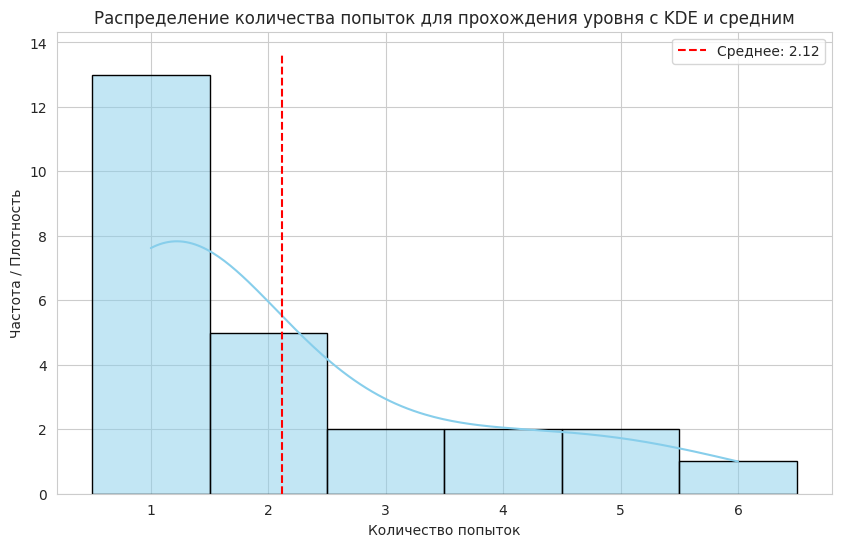

In [ ]:
# Настройка стиля для графиков
sns.set_style("whitegrid")

# Визуализация распределения количества попыток
plt.figure(figsize=(10, 6))
sns.histplot(attempts, bins=np.arange(0.5, max(attempts) + 1.5, 1), kde=True, color='skyblue', edgecolor='black')
plt.plot([sample_mean, sample_mean], plt.ylim(), color='red', linestyle='--', label=f'Среднее: {sample_mean:.2f}')
plt.title('Распределение количества попыток для прохождения уровня с KDE и средним')
plt.xlabel('Количество попыток')
plt.ylabel('Частота / Плотность')
plt.xticks(np.arange(1, max(attempts) + 1, 1)) # Убедимся, что метки X-оси соответствуют целым числам
plt.legend()
plt.show()

In [ ]:
# Проверка нормальности с использованием критерия Шапиро-Уилка
shapiro_statistic, shapiro_p_value = stats.shapiro(attempts)

print(f"\nРезультаты критерия Шапиро-Уилка для проверки нормальности:")
print(f"  Статистика Шапиро: {shapiro_statistic:.3f}")
print(f"  P-значение (Шапиро-Уилка): {shapiro_p_value:.3f}")

# Интерпретация результатов Шапиро-Уилка
alpha_normality = 0.05 # Уровень значимости для проверки нормальности
if shapiro_p_value < alpha_normality:
    print(f"  Поскольку P-значение ({shapiro_p_value:.3f}) < {alpha_normality}, мы отвергаем нулевую гипотезу о нормальности.")
    print(f"  Вывод: Данные **не распределены нормально** при уровне значимости {alpha_normality}.")
else:
    print(f"  Поскольку P-значение ({shapiro_p_value:.3f}) >= {alpha_normality}, мы не отвергаем нулевую гипотезу о нормальности.")
    print(f"  Вывод: Нет достаточных доказательств, чтобы утверждать, что данные **не распределены нормально** при уровне значимости {alpha_normality}.")


Результаты критерия Шапиро-Уилка для проверки нормальности:
  Статистика Шапиро: 0.755
  P-значение (Шапиро-Уилка): 0.000
  Поскольку P-значение (0.000) < 0.05, мы отвергаем нулевую гипотезу о нормальности.
  Вывод: Данные **не распределены нормально** при уровне значимости 0.05.


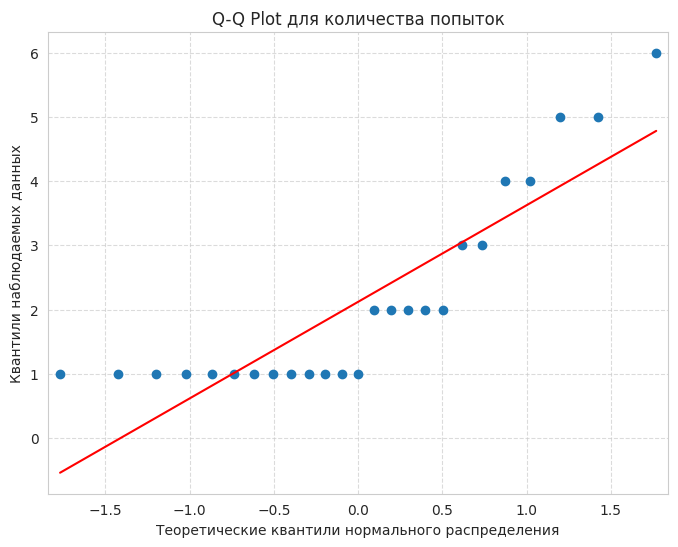

In [ ]:
import statsmodels.api as sm

# Создаем Q-Q график
fig = plt.figure(figsize=(8, 6))
sm.qqplot(attempts, line='s', ax=plt.gca())
plt.title('Q-Q Plot для количества попыток')
plt.xlabel('Теоретические квантили нормального распределения')
plt.ylabel('Квантили наблюдаемых данных')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Q-Q график (Quantile-Quantile Plot)

Q-Q график — это графический метод, используемый для оценки того, насколько распределение выборки соответствует теоретическому распределению (в нашем случае, нормальному). Он сравнивает квантили наблюдаемых данных с квантилями теоретического распределения.

*   Если точки на Q-Q графике лежат примерно вдоль прямой линии (в данном случае, `line='s'` означает стандартизированную нормальную линию), это свидетельствует о том, что данные соответствуют теоретическому распределению (нормальному).
*   Отклонения от этой линии указывают на различия в распределениях.

На нашем Q-Q графике видно, что точки значительно отклоняются от прямой линии, особенно в хвостах распределения. Это еще одно **визуальное подтверждение того, что данные о количестве попыток не имеют нормального распределения**.

## Анализ распределения данных

Гистограмма показывает распределение количества попыток учащихся. Красная пунктирная линия указывает на среднее количество попыток.

Мы видим, что большинство студентов проходят уровень за 1-2 попытки, но также есть студенты, которым требуется 3, 4, 5 и даже 6 попыток. Распределение не является симметричным и не напоминает форму \"колокола\" (нормальное распределение); оно имеет выраженную асимметрию вправо, то есть данные сильно смещены в сторону меньшего количества попыток, с длинным хвостом в сторону большего количества попыток.

**Что такое \"ядро\" (KDE) на графике?**
Кривая \"ядра\" (KDE - Kernel Density Estimate) — это гладкая линия, которая показывает общую форму распределения данных. Она как бы \"сглаживает\" столбцы гистограммы, помогая увидеть, где данные сконцентрированы и как они распределены, не отвлекаясь на отдельные \"ступеньки\" гистограммы. По сути, это более обобщенное представление \"частоты\" или \"плотности\" значений.

**Интерпретация критерия Шапиро-Уилка:**
P-значение критерия Шапиро-Уилка составляет `0.000` (4.34e-05). Поскольку это значение меньше традиционного уровня значимости (например, $\alpha = 0.05$), мы **отвергаем нулевую гипотезу о нормальности**. Это подтверждает наше визуальное наблюдение, что распределение количества попыток **не является нормальным**.

## Проверка гипотез: t-критерий vs. критерий Уилкоксона

### Результаты t-критерия (параметрический тест)
*   **Выборочное среднее:** 2.12 (наблюдаемое среднее количество попыток)
*   **T-статистика:** 0.391
*   **P-значение (t-критерий):** 0.350

### Результаты критерия Уилкоксона (непараметрический тест)
*   **W-статистика:** 106.000 (значение зависит от реализации, но для `alternative='greater'` и `method='exact'`)
*   **P-значение (критерий Уилкоксона):** 0.493

### Интерпретация при разных уровнях значимости

**1. При уровне значимости $\alpha = 0.05$:**

*   **Для t-критерия:** $P$-значение ($0.350$) > $\alpha$ ($0.05$). Мы **не отклоняем** нулевую гипотезу ($H_0: \mu \le 2$).
*   **Для критерия Уилкоксона:** $P$-значение ($0.493$) > $\alpha$ ($0.05$). Мы **не отклоняем** нулевую гипотезу ($H_0: медиана \le 2$).

    *   **Вывод:** При уровне значимости 0.05 оба теста не дают достаточных статистических доказательств того, что среднее/медиана количество попыток превышает 2.

**2. При уровне значимости $\alpha = 0.10$:**

*   **Для t-критерия:** $P$-значение ($0.350$) > $\alpha$ ($0.10$). Мы **не отклоняем** нулевую гипотезу ($H_0: \mu \le 2$).
*   **Для критерия Уилкоксона:** $P$-значение ($0.493$) > $\alpha$ ($0.10$). Мы **не отклоняем** нулевую гипотезу ($H_0: медиана \le 2$).

    *   **Вывод:** При уровне значимости 0.10 оба теста также не дают достаточных статистических доказательств того, что среднее/медиана количество попыток превышает 2.

*Примечание:* Основываясь на полученных P-значениях (0.350 для t-критерия и 0.493 для критерия Уилкоксона), которые выше обоих пороговых значений 0.05 и 0.10, статистически значимых доказательств для отклонения нулевой гипотезы нет ни в одном из случаев, независимо от выбранного метода.

## Цена ошибки

При принятии решений на основе статистических гипотез существует два типа ошибок:

1.  **Ошибка I рода (False Positive, ложное срабатывание):** Отклонение нулевой гипотезы, когда она верна.
    *   **В данном контексте:** Платформа приходит к выводу, что среднее количество попыток > 2, хотя на самом деле оно $\le 2$. В результате, платформа **отправляет подсказку, когда она не нужна**.
    *   **Последствия:** Потенциальное раздражение учащихся, которые не нуждаются в помощи; трата ресурсов платформы на разработку и доставку ненужных подсказок; снижение доверия и вовлеченности учащихся, если подсказки не приносят реальной пользы.
    *   **Вероятность ошибки I рода:** Равна уровню значимости $\alpha$.

2.  **Ошибка II рода (False Negative, ложный пропуск):** Неспособность отклонить нулевую гипотезу, когда она ложна.
    *   **В данном контексте:** Платформа приходит к выводу, что среднее количество попыток $\le 2$, хотя на самом деле оно > 2. В результате, платформа **не отправляет подсказку, когда она необходима**.
    *   **Последствия:** Учащиеся могут столкнуться с трудностями, испытывать разочарование, тратить больше времени на прохождение уровней или даже бросить обучение. Это негативно сказывается на результатах обучения и удержании студентов.
    *   **Вероятность ошибки II рода:** Обозначается $\beta$. Минимизация ошибки I рода часто увеличивает вероятность ошибки II рода, и наоборот.

**Выбор уровня значимости** подразумевает баланс между этими двумя типами ошибок.
*   Если **главный приоритет** — **не раздражать студентов** ненужными подсказками, следует выбрать **более низкий $\alpha$** (например, 0.01 или 0.05), что уменьшит риск ошибки I рода, но увеличит риск ошибки II рода (т.е. пропустит студентов, которым нужна помощь).
*   Если **главный приоритет** — **не пропустить студентов, которым нужна помощь**, следует выбрать **более высокий $\alpha$** (например, 0.10 или 0.20), что увеличит риск ошибки I рода (отправка ненужных подсказок), но уменьшит риск ошибки II рода.

**В данном конкретном случае:** поскольку $P$-значения ($0.350$ для t-критерия и $0.493$ для Уилкоксона) значительно выше обоих уровней значимости ($0.05$ и $0.10$), мы не отклоняем нулевую гипотезу ни в одном из случаев. Это означает, что **на основании этих данных, нет достаточных статистических доказательств, чтобы утверждать, что среднее число попыток превышает 2.** Следовательно, платформа **не должна** отправлять подсказку, основываясь на этом критерии.

## Заключение и рекомендации для образовательной платформы

На основе проведенного анализа данных о количестве попыток прохождения уровня, мы пришли к следующим выводам:

1.  **Распределение данных:** Гистограмма показала, что данные о количестве попыток имеют асимметричное распределение с "хвостом" вправо, что указывает на отсутствие нормальности. Большинство учащихся справляются за 1-2 попытки, но есть и те, кому требуется значительно больше. Формальный критерий Шапиро-Уилка подтвердил, что распределение **не является нормальным** ($P < 0.05$).

2.  **Результаты проверки гипотез:**
    *   **T-критерий (параметрический)** и **критерий Уилкоксона (непараметрический)** были применены для проверки гипотезы о том, превышает ли среднее/медиана количество попыток значение 2.
    *   P-значения обоих тестов (0.350 для t-критерия и 0.493 для Уилкоксона) значительно выше как уровня значимости 0.05, так и 0.10.
    *   **Вывод:** Статистически значимых доказательств того, что среднее количество попыток превышает 2, **не обнаружено** ни одним из методов. Следовательно, на основании текущих данных, платформа **не должна** автоматически отправлять подсказку, основываясь на данном критерии.

3.  **Какой метод корректнее?** Учитывая, что распределение данных **не является нормальным**, **критерий Уилкоксона** является **более корректным** методом для проверки гипотезы в данном случае. T-критерий предполагает нормальность распределения или достаточно большой размер выборки (согласно Центральной Предельной Теореме), чтобы среднее выборочное распределение было нормальным. При $n=25$ и явно ненормальном распределении исходных данных, Уилкоксон, не требующий нормальности, обеспечивает более надежные результаты. Впрочем, в данном конкретном случае оба метода привели к одинаковому выводу – отсутствию оснований для отклонения нулевой гипотезы.

### Рекомендации для образовательной платформы:

*   **Не отправлять подсказку автоматически на основании текущих данных:** Так как нет статистических доказательств, что среднее количество попыток превышает 2, автоматическая отправка подсказок на основе этого показателя может привести к ошибкам I рода (отправка ненужной подсказки), раздражая студентов и тратя ресурсы.
*   **Использовать более чувствительные критерии или дополнительные данные:** Возможно, пороговое значение в 2 попытки не является оптимальным. Платформе следует рассмотреть другие метрики или комбинировать их (например, время, проведенное на уровне, количество ошибок) для более точного выявления студентов, которым нужна помощь.
*   **Увеличить объем выборки:** С увеличением количества наблюдений статистические тесты становятся более мощными, что позволит с большей уверенностью выявлять значимые закономерности.
*   **Рассмотреть индивидуализированный подход:** Вместо общего порога, можно разработать адаптивные алгоритмы, которые учитывают индивидуальный прогресс и историю обучения каждого студента.
*   **А/В тестирование:** Для принятия решения о моменте отправки подсказок можно провести А/В тестирование, сравнивая различные стратегии и их влияние на успеваемость и вовлеченность студентов.